In [1]:
import tensorflow as tf
import os

# Get list of GPUs
physical_devices = tf.config.list_physical_devices('GPU')

if physical_devices:
    # Limit GPU to 3GB only — no memory growth needed
    # (can't use both memory growth AND virtual device limit together)
    tf.config.experimental.set_virtual_device_configuration(
        physical_devices[0],
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072)]
    )
    print(' GPU found and configured — 3GB limit set!')
else:
    print(' No GPU found')

# Async allocator helps prevent OOM errors
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
print(' GPU allocator set!')

 GPU found and configured — 3GB limit set!
 GPU allocator set!


## Cell 1 — Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.10.0
NumPy version: 1.23.5


## Cell 2 — Configuration
Only edit this cell to change settings!

In [3]:
# ============================================================
#   SETTINGS — only edit these
# ============================================================

EPOCHS         = 27          # start with 5 to test, increase later
BATCH_SIZE     = 2       # safe for 16GB RAM
LEARNING_RATE  = 1e-4         # same as model_building notebook

# Paths — data
X_TRAIN_PATH   = '../data/X.npy'
Y_TRAIN_PATH   = '../data/Y.npy'
X_TEST_PATH    = '../data/X_test.npy'
Y_TEST_PATH    = '../data/Y_test.npy'

# Paths — saving
SAVE_DIR        = '../models'
BEST_MODEL_PATH = '../models/best_model.keras'
CHECKPOINT_PATH = '../models/checkpoint.keras'
HISTORY_PATH    = '../models/history.npy'

os.makedirs(SAVE_DIR,      exist_ok=True)
os.makedirs('../outputs',  exist_ok=True)

print('Config ready!')
print(f'   Epochs     : {EPOCHS}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Models dir : {SAVE_DIR}')

Config ready!
   Epochs     : 27
   Batch size : 2
   Models dir : ../models


## Cell 3 — Load Data

In [4]:
# Load full training data
print('Loading training data...')
X_full = np.load(X_TRAIN_PATH).astype(np.float32)   # float32 = half memory!
Y_full = np.load(Y_TRAIN_PATH).astype(np.float32) 

# Split into train (80%) and validation (20%)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_full, Y_full,
    test_size=0.2,
    random_state=42
)

# Load test data — only used at the end
print('Loading test data...')
X_test = np.load(X_TEST_PATH).astype(np.float32)   # float32 = half memory!
Y_test = np.load(Y_TEST_PATH).astype(np.float32)   # float32 = half memory!

# Add channel dimension to masks
if Y_train.ndim == 3:
    Y_train = np.expand_dims(Y_train, axis=-1)
if Y_val.ndim == 3:
    Y_val = np.expand_dims(Y_val, axis=-1)
if Y_test.ndim == 3:
    Y_test = np.expand_dims(Y_test, axis=-1)

print(f'X_train : {X_train.shape}  ← model learns from this')
print(f'X_val   : {X_val.shape}    ← checks progress during training')
print(f'X_test  : {X_test.shape}   ← final evaluation only')

Loading training data...
Loading test data...
X_train : (3146, 256, 256, 3)  ← model learns from this
X_val   : (787, 256, 256, 3)    ← checks progress during training
X_test  : (860, 256, 256, 3)   ← final evaluation only


## Cell 4 — Custom Loss & Metrics
Exact same as notebook 3.

In [5]:
# Dice Coefficient
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

# Dice Loss
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# BCE + Dice Loss
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# IoU Metric
def iou(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = (
        tf.keras.backend.sum(y_true_f)
        + tf.keras.backend.sum(y_pred_f)
        - intersection
    )
    return (intersection + smooth) / (union + smooth)

print('Loss functions and metrics defined!')

Loss functions and metrics defined!


## Cell 5 — Build U-Net Model
Exact same architecture as notebook 3.

In [6]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder Block 1 — 32 filters
    c1 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32,  (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    # Encoder Block 2 — 64 filters
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # Encoder Block 3 — 128 filters
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    # Encoder Block 4 — 256 filters
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    # Bottleneck — 512 filters
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c5)

    # Decoder Block 1
    u6 = layers.UpSampling2D((2,2))(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c6)

    # Decoder Block 2
    u7 = layers.UpSampling2D((2,2))(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c7)

    # Decoder Block 3
    u8 = layers.UpSampling2D((2,2))(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c8)

    # Decoder Block 4
    u9 = layers.UpSampling2D((2,2))(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c9)

    # Output layer — sigmoid for binary segmentation
    outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(c9)

    return models.Model(inputs, outputs)


model = build_unet(input_shape=(256, 256, 3))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou, 'accuracy']
)

print(' U-Net model built and compiled!')
print(f'   Total parameters: {model.count_params():,}')

 U-Net model built and compiled!
   Total parameters: 7,846,657


## Cell 6 — Load Checkpoint
Auto-resumes from where you stopped last time.

In [7]:
initial_epoch = 0
history_data  = {}

if os.path.exists(CHECKPOINT_PATH):
    print(f' Checkpoint found! Loading from: {CHECKPOINT_PATH}')
    model.load_weights(CHECKPOINT_PATH)

    if os.path.exists(HISTORY_PATH):
        history_data  = np.load(HISTORY_PATH, allow_pickle=True).item()
        initial_epoch = len(history_data.get('loss', []))
        print(f'   History shows {initial_epoch} epochs completed')
        print(f'   Resuming from epoch {initial_epoch + 1} → {EPOCHS}')
    else:
        print('   No history found — starting fresh')
else:
    print('No checkpoint found. Starting from epoch 1.')

 Checkpoint found! Loading from: ../models/checkpoint.keras
   History shows 27 epochs completed
   Resuming from epoch 28 → 27


## Cell 7 — Callbacks

In [8]:
import numpy as np

class SaveHistoryCallback(tf.keras.callbacks.Callback):
    """Saves history after every epoch so it never gets lost on crash"""
    def __init__(self, history_path, history_data):
        super().__init__()
        self.history_path = history_path
        self.history_data = history_data
    
    def on_epoch_end(self, epoch, logs=None):
        for key, value in logs.items():
            if key in self.history_data:
                self.history_data[key].append(float(value))
            else:
                self.history_data[key] = [float(value)]
        np.save(self.history_path, self.history_data)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_dice_coef',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_best_only=False,
        verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        mode='max',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    SaveHistoryCallback(HISTORY_PATH, history_data)
]

print(' Callbacks ready!')
print('   • Best model  → saved when val dice improves')
print('   • Checkpoint  → saved after every epoch')
print('   • LR Reducer  → reduces LR if stuck for 5 epochs')
print('   • Early Stop  → stops if no improvement for 15 epochs')
print('   • History     → saved after every epoch automatically!')

 Callbacks ready!
   • Best model  → saved when val dice improves
   • Checkpoint  → saved after every epoch
   • LR Reducer  → reduces LR if stuck for 5 epochs
   • Early Stop  → stops if no improvement for 15 epochs
   • History     → saved after every epoch automatically!


## Cell 8 — Train 


In [9]:
print(' Starting training...')
print(f'   From epoch  : {initial_epoch + 1}')
print(f'   To epoch    : {EPOCHS}')
print(f'   Batch size  : {BATCH_SIZE}')
print(f'   Train size  : {len(X_train)}')
print(f'   Test size   : {len(X_test)}')
print('=' * 60)

history = model.fit(
    X_train, Y_train,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

# Merge history with previous runs
for key in history.history:
    if key in history_data:
        history_data[key] = history_data[key] + history.history[key]
    else:
        history_data[key] = history.history[key]

# Save history
np.save(HISTORY_PATH, history_data)

print('\n Training complete!')
print(f'   Best model → {BEST_MODEL_PATH}')
print(f'   History    → {HISTORY_PATH}')

 Starting training...
   From epoch  : 28
   To epoch    : 27
   Batch size  : 2
   Train size  : 3146
   Test size   : 860

 Training complete!
   Best model → ../models/best_model.keras
   History    → ../models/history.npy


## Cell 9 — Plot Training Curves

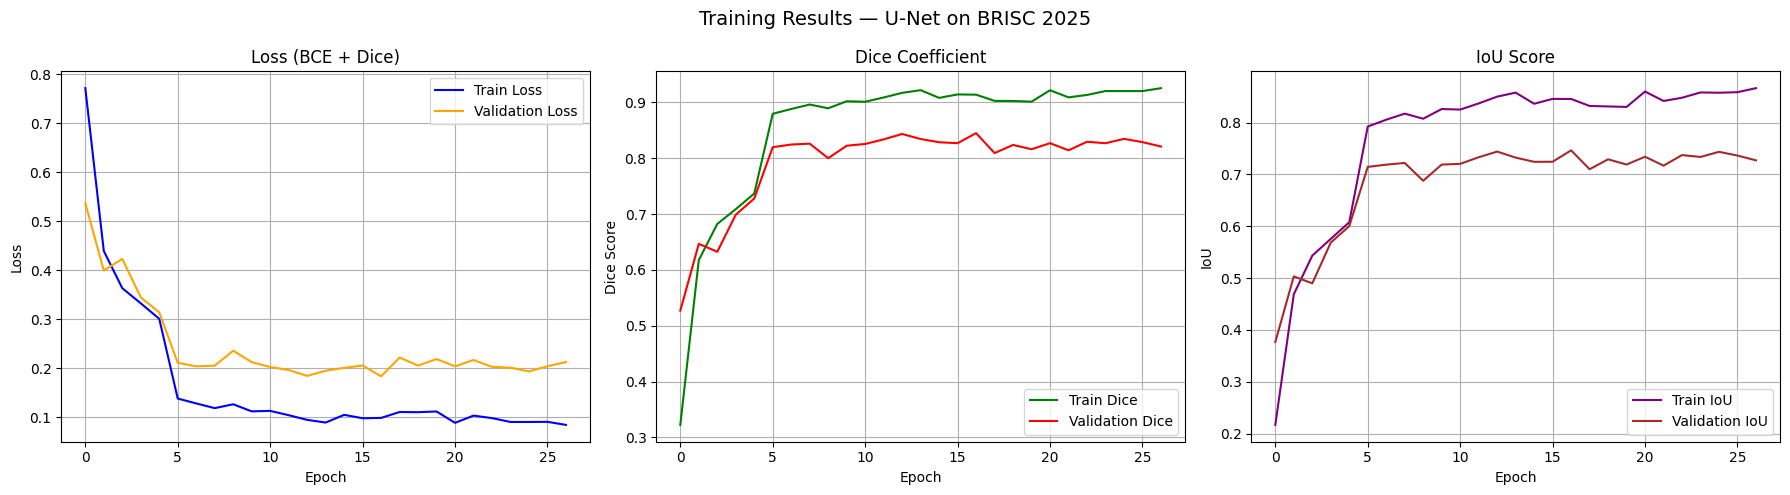

 Curves saved to ../outputs/training_curves.png


In [10]:
# Load history
if os.path.exists(HISTORY_PATH):
    history_data = np.load(HISTORY_PATH, allow_pickle=True).item()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Results — U-Net on BRISC 2025', fontsize=14)

# Loss
axes[0].plot(history_data['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_data['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Dice
axes[1].plot(history_data['dice_coef'],     label='Train Dice',      color='green')
axes[1].plot(history_data['val_dice_coef'], label='Validation Dice', color='red')
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()
axes[1].grid(True)

# IoU
axes[2].plot(history_data['iou'],     label='Train IoU',      color='purple')
axes[2].plot(history_data['val_iou'], label='Validation IoU', color='brown')
axes[2].set_title('IoU Score')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('../outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Curves saved to ../outputs/training_curves.png')

## Cell 10 — Final Evaluation

In [11]:
# Load best model
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef'    : dice_coef,
        'iou'          : iou
    }
)

results = best_model.evaluate(X_test, Y_test, verbose=1)

print('\n Final Results on Test Set:')
print(f'   Loss       : {results[0]:.4f}')
print(f'   Dice Score : {results[1]:.4f}')
print(f'   IoU        : {results[2]:.4f}')
print(f'   Accuracy   : {results[3]:.4f}')

if results[1] >= 0.90:
    print('\n Excellent! Dice >= 0.90')
elif results[1] >= 0.75:
    print('\n Good! Dice >= 0.75')
else:
    print('\n  Dice below 0.75 — train more epochs.')

27/27 [==============================] - 175s 3s/step - loss: 0.1803 - dice_coef: 0.8488 - iou: 0.7500 - accuracy: 0.9896

 Final Results on Test Set:
   Loss       : 0.1803
   Dice Score : 0.8488
   IoU        : 0.7500
   Accuracy   : 0.9896

 Good! Dice >= 0.75


## Cell 11 — Visualize Predictions

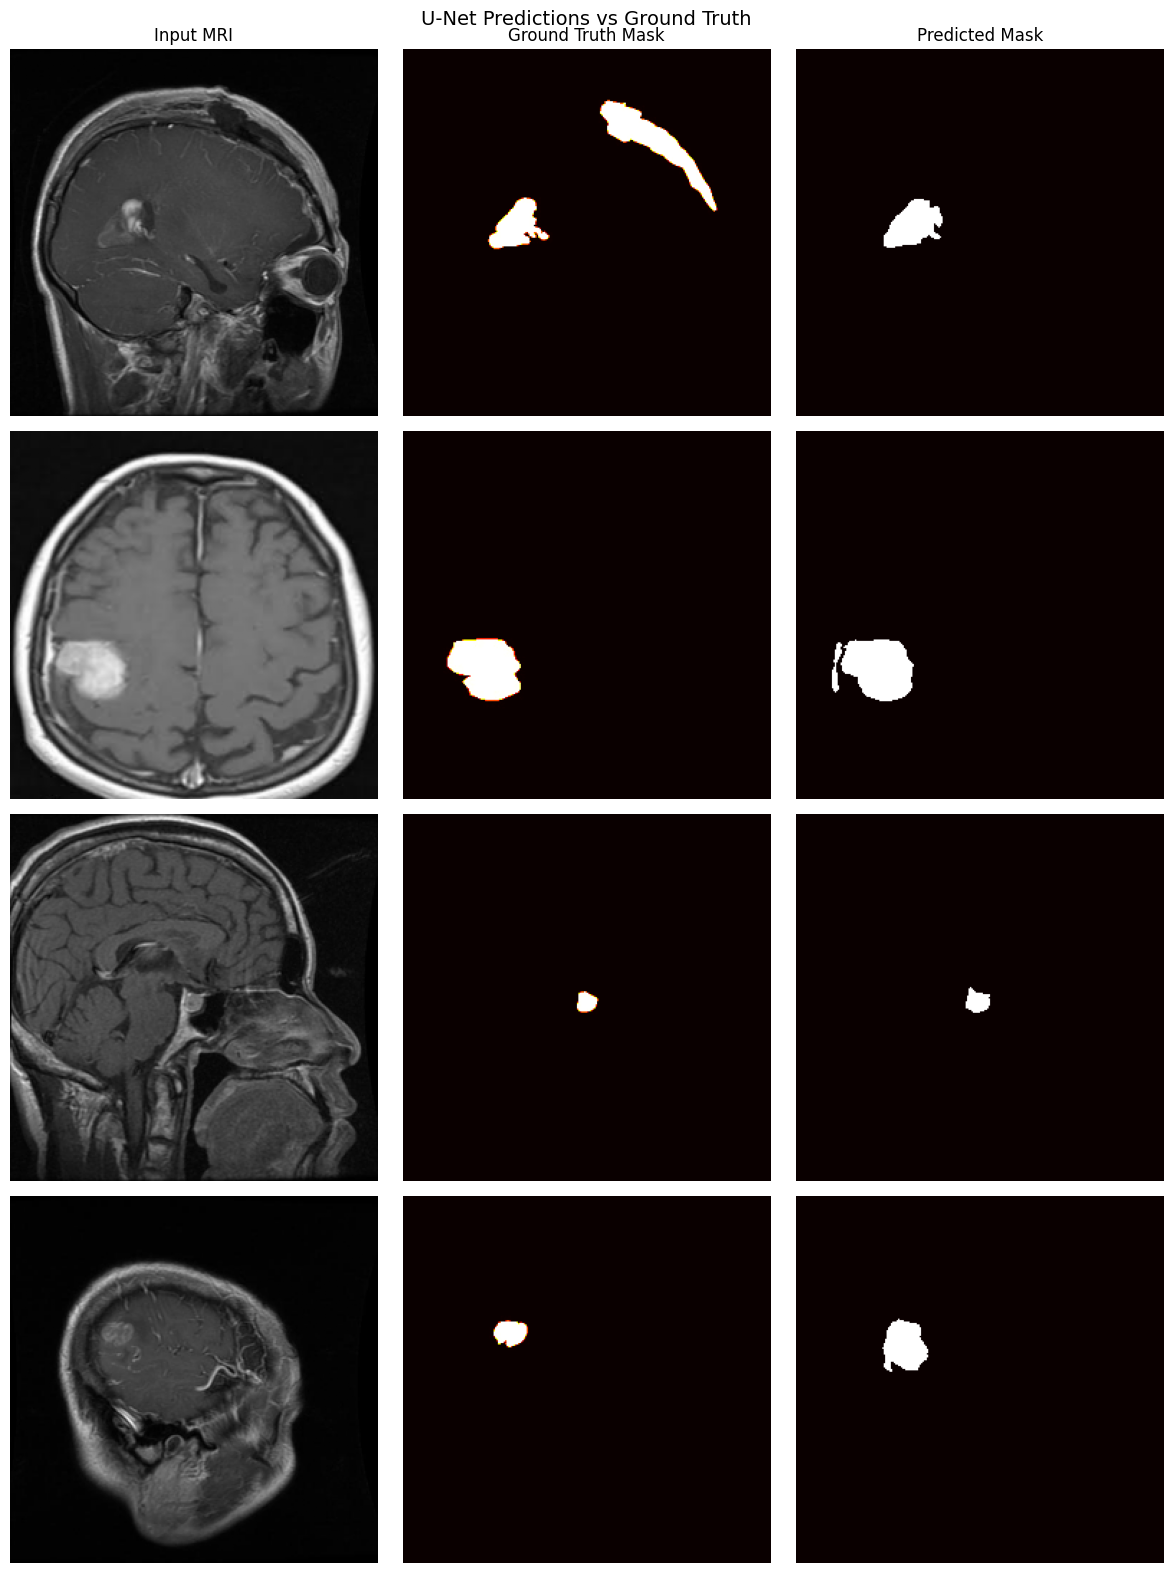

Predictions saved to ../outputs/predictions.png


In [12]:
# Pick 4 random samples from test set
sample_indices = np.random.choice(len(X_test), 4, replace=False)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('U-Net Predictions vs Ground Truth', fontsize=14)

for col, title in enumerate(['Input MRI', 'Ground Truth Mask', 'Predicted Mask']):
    axes[0, col].set_title(title, fontsize=12)

for row, idx in enumerate(sample_indices):
    img  = X_test[idx]           # (256, 256, 3)
    mask = Y_test[idx].squeeze() # (256, 256)

    pred = best_model.predict(
        np.expand_dims(img, axis=0), verbose=0
    )[0].squeeze()
    pred_binary = (pred > 0.5).astype(np.uint8)

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask, cmap='hot')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_binary, cmap='hot')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Predictions saved to ../outputs/predictions.png')

In [13]:
# ============================================================
# TRAINING VERIFICATION CELL
# Run this to confirm training is complete and correct
# ============================================================
import numpy as np
import os

print("=" * 60)
print("   TRAINING COMPLETION VERIFICATION")
print("=" * 60)

# Check 1 — Model files exist
print("\n📁 Model Files:")
files = {
    'best_model.keras' : BEST_MODEL_PATH,
    'checkpoint.keras' : CHECKPOINT_PATH,
    'history.npy'      : HISTORY_PATH
}
for name, path in files.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / (1024*1024) if exists else 0
    print(f"   {'✅' if exists else '❌'} {name} — {size:.1f} MB")

# Check 2 — History summary
print("\n📊 Training History:")
history_data = np.load(HISTORY_PATH, allow_pickle=True).item()
epochs_done  = len(history_data.get('loss', []))
best_val_dice = max(history_data.get('val_dice_coef', [0]))
best_epoch    = history_data.get('val_dice_coef', [0]).index(best_val_dice) + 1
final_train_dice = history_data.get('dice_coef', [0])[-1]
final_val_dice   = history_data.get('val_dice_coef', [0])[-1]

print(f"   Total epochs trained : {epochs_done}")
print(f"   Best Val Dice        : {best_val_dice:.4f} (epoch {best_epoch})")
print(f"   Final Train Dice     : {final_train_dice:.4f}")
print(f"   Final Val Dice       : {final_val_dice:.4f}")

# Check 3 — Test results
print("\n🧪 Test Set Results:")
print(f"   Dice Score : {results[1]:.4f}")
print(f"   IoU        : {results[2]:.4f}")
print(f"   Accuracy   : {results[3]:.4f}")

# Check 4 — Overall verdict
print("\n🏆 Overall Verdict:")
if results[1] >= 0.85:
    print("   EXCELLENT — Dice >= 0.85 ✅")
elif results[1] >= 0.75:
    print("   GOOD — Dice >= 0.75 ✅")
else:
    print("   NEEDS MORE TRAINING ⚠️")

print("\n" + "=" * 60)
print("   Training file is COMPLETE and CORRECT! ✅")
print("=" * 60)

   TRAINING COMPLETION VERIFICATION

📁 Model Files:
   ✅ best_model.keras — 90.0 MB
   ✅ checkpoint.keras — 90.0 MB
   ✅ history.npy — 0.0 MB

📊 Training History:
   Total epochs trained : 27
   Best Val Dice        : 0.8448 (epoch 17)
   Final Train Dice     : 0.9254
   Final Val Dice       : 0.8209

🧪 Test Set Results:
   Dice Score : 0.8488
   IoU        : 0.7500
   Accuracy   : 0.9896

🏆 Overall Verdict:
   GOOD — Dice >= 0.75 ✅

   Training file is COMPLETE and CORRECT! ✅


---
##  Done!

| File | What it is |
|---|---|
| `../models/best_model.keras` | Best model by test Dice score |
| `../models/checkpoint.keras` | Latest checkpoint for resuming |
| `../models/history.npy` | Training history |
| `../outputs/training_curves.png` | Loss & metric plots |
| `../outputs/predictions.png` | Visual predictions |


###  Target scores:
| Dice Score | Meaning |
|---|---|
| > 0.90 | Excellent |
| > 0.75 | Good |
| < 0.75 | Train more epochs |